In [1]:
import pandas as pd
import numpy as np
import gcsfs
from joblib import Parallel, delayed
import seaborn as sns
import matplotlib.pyplot as plt
from uszipcode import SearchEngine

/opt/anaconda3/lib/python3.13/site-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


## 1. Load Data

In [2]:
# making sure this works - it does
#fs = gcsfs.GCSFileSystem(project='cse6242-project-476314', token = 'google_default')
#with fs.open('cse6242-project-data-bucket/Zip_zori_uc_sfrcondomfr_sm_sa_month.csv') as f:
#    zori_wide = pd.read_csv(f)

# use local for initial testing
zori_wide = pd.read_csv('Zip_zori_uc_sfrcondomfr_sm_sa_month.csv')
zori_wide

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,2015-01-31,...,2024-12-31,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30
0,91982,1,77494,zip,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,1501.705581,...,1902.035623,1902.589323,1894.295923,1891.247836,1889.899732,1889.783368,1886.582030,1887.378619,1888.256767,1891.123162
1,91940,3,77449,zip,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Harris County,1252.988450,...,1834.055010,1834.801216,1836.145502,1835.505043,1831.819858,1833.617479,1829.740778,1831.288573,1825.781679,1829.945544
2,91733,5,77084,zip,TX,TX,Houston,"Houston-The Woodlands-Sugar Land, TX",Harris County,1127.656461,...,1625.302516,1624.803898,1632.635241,1632.612081,1630.639582,1615.873819,1614.456853,1619.566427,1630.300973,1634.061782
3,93144,6,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,NaN,...,1426.444928,1435.425031,1443.855231,1446.723283,1441.421688,1439.302928,1441.642569,1448.088589,1456.518933,1463.357895
4,62093,7,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,NaN,...,3150.113998,3186.884070,3216.427094,3224.476398,3223.466612,3234.890106,3255.649669,3275.779831,3277.512495,3300.138507
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7848,418163,30158,89158,zip,NV,NV,Las Vegas,"Las Vegas-Henderson-Paradise, NV",Clark County,NaN,...,NaN,NaN,NaN,NaN,NaN,3066.735205,3141.404502,3220.651060,NaN,3383.333333
7849,70410,30172,29333,zip,SC,SC,Spartanburg,"Spartanburg, SC",Spartanburg County,NaN,...,NaN,NaN,NaN,NaN,1496.722526,1492.599968,1467.567991,1471.938011,1447.380379,1441.444444
7850,61618,30490,10004,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",New York County,NaN,...,4953.861191,4992.794726,5020.881625,4966.573186,4993.118270,4985.137479,5019.837773,5064.354786,5128.502857,5207.319444
7851,91179,30490,76005,zip,TX,TX,Arlington,"Dallas-Fort Worth-Arlington, TX",Tarrant County,NaN,...,2266.033986,2269.037047,2240.741193,2237.569443,2215.046263,2215.363392,2210.884130,2224.301864,2214.883471,2216.444444


In [3]:
# get into long format
value_vars = [col for col in zori_wide.columns if col[:4].isdigit()]

zori = zori_wide.melt(
    id_vars=['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 'State', 'City', 'Metro', 'CountyName'],
    value_vars = value_vars,
    var_name='Date',
    value_name='Rent'
)

# format date
zori['Date'] = pd.to_datetime(zori['Date'])
zori['Date'] = zori['Date'].dt.to_period('M').dt.to_timestamp('M')


# rename RegionID to ZIP
zori = zori.rename(columns={'RegionName':'ZIP'})

# sort time series
zori = zori.sort_values(['ZIP', 'Date'])

zori

,RegionID,SizeRank,ZIP,RegionType,StateName,State,City,Metro,CountyName,Date,Rent
3692,58197,3911,1002,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,2015-01-31,NaN
11545,58197,3911,1002,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,2015-02-28,NaN
19398,58197,3911,1002,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,2015-03-31,NaN
27251,58197,3911,1002,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,2015-04-30,NaN
35104,58197,3911,1002,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,2015-05-31,NaN
...,...,...,...,...,...,...,...,...,...,...,...
977970,100459,4499,99801,zip,AK,AK,Juneau,"Juneau, AK",Juneau Borough,2025-05-31,2086.647581
985823,100459,4499,99801,zip,AK,AK,Juneau,"Juneau, AK",Juneau Borough,2025-06-30,2106.771773
993676,100459,4499,99801,zip,AK,AK,Juneau,"Juneau, AK",Juneau Borough,2025-07-31,2071.056317
1001529,100459,4499,99801,zip,AK,AK,Juneau,"Juneau, AK",Juneau Borough,2025-08-31,2061.207785


## 2. Data Inspection

In [4]:
zori.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1013037 entries, 3692 to 1009382
Data columns (total 11 columns):
 #   Column      Non-Null Count    Dtype         
---  ------      --------------    -----         
 0   RegionID    1013037 non-null  int64         
 1   SizeRank    1013037 non-null  int64         
 2   ZIP         1013037 non-null  int64         
 3   RegionType  1013037 non-null  object        
 4   StateName   1013037 non-null  object        
 5   State       1013037 non-null  object        
 6   City        1005555 non-null  object        
 7   Metro       1008006 non-null  object        
 8   CountyName  1013037 non-null  object        
 9   Date        1013037 non-null  datetime64[ns]
 10  Rent        396233 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(6)
memory usage: 92.7+ MB


In [5]:
zori.describe()

,RegionID,SizeRank,ZIP,Date,Rent
count,1.013037e+06,1.013037e+06,1.013037e+06,1013037,396233.000000
mean,8.469800e+04,4.770870e+03,5.263820e+04,2020-05-30 20:39:04.186046720,1814.321472
min,5.819700e+04,1.000000e+00,1.002000e+03,2015-01-31 00:00:00,528.828904
25%,7.036500e+04,2.037000e+03,2.915000e+04,2017-09-30 00:00:00,1301.376023
50%,7.948800e+04,4.178000e+03,4.842300e+04,2020-05-31 00:00:00,1649.037387
75%,9.326100e+04,6.735000e+03,7.993200e+04,2023-01-31 00:00:00,2128.800125
max,8.459140e+05,3.049000e+04,9.980100e+04,2025-09-30 00:00:00,99629.555556
std,4.216436e+04,3.566825e+03,2.993071e+04,NaN,1108.741032


## 3. Handle Missingness

In [6]:
zori.isna().sum()

RegionID           0
SizeRank           0
ZIP                0
RegionType         0
StateName          0
State              0
City            7482
Metro           5031
CountyName         0
Date               0
Rent          616804
dtype: int64

### A. Rent


#### Check for extreme spacing between dates

In [7]:
# spacing
zori['gap_days']  = zori.groupby('ZIP')['Date'].diff().dt.days
anomalies = zori[zori['gap_days'] > 31]
anomalies.head()

,RegionID,SizeRank,ZIP,RegionType,StateName,State,City,Metro,CountyName,Date,Rent,gap_days


In [8]:
# standardize the time line
full_index = pd.date_range('2015-01-01', '2024-12-01', freq='ME')

zori2 = zori.copy()
zori2['Date'] = pd.to_datetime(zori2['Date']).dt.to_period('M').dt.to_timestamp('M')

zori2 = (
    zori2
    .set_index('Date')
    .groupby('ZIP')
    .apply(lambda x: x.drop(columns='ZIP').reindex(full_index)) 
    .rename_axis(index=['ZIP', 'Date'])
    .reset_index()  
)

zori2

/var/folders/v6/rt7shrqx5sldb75bkwymnhlw0000gp/T/ipykernel_30524/3084138725.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.drop(columns='ZIP').reindex(full_index))


,ZIP,Date,RegionID,SizeRank,RegionType,StateName,State,City,Metro,CountyName,Rent,gap_days
0,1002,2015-01-31,58197,3911,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,NaN,NaN
1,1002,2015-02-28,58197,3911,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,NaN,28.0
2,1002,2015-03-31,58197,3911,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,NaN,31.0
3,1002,2015-04-30,58197,3911,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,NaN,30.0
4,1002,2015-05-31,58197,3911,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,NaN,31.0
...,...,...,...,...,...,...,...,...,...,...,...,...
934502,99801,2024-07-31,100459,4499,zip,AK,AK,Juneau,"Juneau, AK",Juneau Borough,NaN,31.0
934503,99801,2024-08-31,100459,4499,zip,AK,AK,Juneau,"Juneau, AK",Juneau Borough,NaN,31.0
934504,99801,2024-09-30,100459,4499,zip,AK,AK,Juneau,"Juneau, AK",Juneau Borough,NaN,30.0
934505,99801,2024-10-31,100459,4499,zip,AK,AK,Juneau,"Juneau, AK",Juneau Borough,NaN,31.0


#### Missingness of rent by state

In [9]:
zip_missing = (
    zori2.groupby(['State', 'ZIP'])['Rent']
        .apply(lambda s: s.isna().sum())
        .reset_index(name='missing')
)

zip_missing.groupby('State')['missing'].apply(lambda x: (x > 0).mean()).sort_values()

State
NV    0.581395
AZ    0.620321
FL    0.771982
GA    0.810700
VA    0.859223
NY    0.869919
NC    0.874459
TX    0.893408
DC    0.909091
NM    0.921053
CA    0.926045
MA    0.926966
IL    0.928287
ID    0.931818
HI    0.933333
RI    0.939394
CO    0.939560
MD    0.941176
TN    0.945578
WA    0.950226
SC    0.957983
MI    0.961722
OR    0.967480
PA    0.967742
OK    0.970588
IN    0.974684
NJ    0.978166
CT    0.980952
MO    0.981013
AR    0.983051
KS    0.986667
MN    0.992806
OH    0.996154
AK    1.000000
VT    1.000000
WI    1.000000
SD    1.000000
UT    1.000000
MS    1.000000
NE    1.000000
ND    1.000000
MT    1.000000
WV    1.000000
ME    1.000000
LA    1.000000
KY    1.000000
IA    1.000000
DE    1.000000
AL    1.000000
NH    1.000000
WY    1.000000
Name: missing, dtype: float64

#### Missingness of Rent by Time

In [10]:
missing_by_month = (
    zori2.groupby('Date')['Rent']
        .apply(lambda s: s.isna().mean())
        .reset_index(name='pct_missing')
)

missing_by_month

,Date,pct_missing
0,2015-01-31,0.895454
1,2015-02-28,0.891761
2,2015-03-31,0.884885
3,2015-04-30,0.883102
4,2015-05-31,0.880810
...,...,...
114,2024-07-31,0.282695
115,2024-08-31,0.281166
116,2024-09-30,0.277601
117,2024-10-31,0.267923


<Axes: xlabel='Date'>

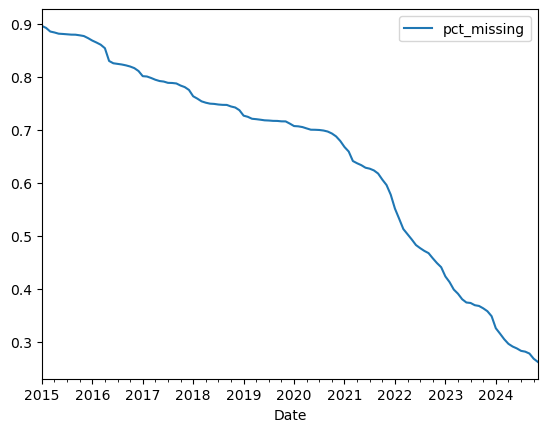

In [11]:
missing_by_month.plot(x='Date', y='pct_missing')

#### Missing Spans Per Zip

In [12]:
def missing_streak_length(series):
    return series.isna().groupby((~series.isna()).cumsum()).sum().max()

zip_missing_streak = (
    zori2.groupby('ZIP')['Rent']
        .apply(missing_streak_length)
        .reset_index(name='max_missing_streak')
)

zip_missing_streak.sort_values('max_missing_streak', ascending=False).head()

,ZIP,max_missing_streak
3926,48423,119
3643,46036,119
3647,46052,119
3648,46055,119
3651,46064,119


#### ZIP x Time Heatmap

Text(0.5, 1.0, 'Missing Rent Data by ZIP × Month')

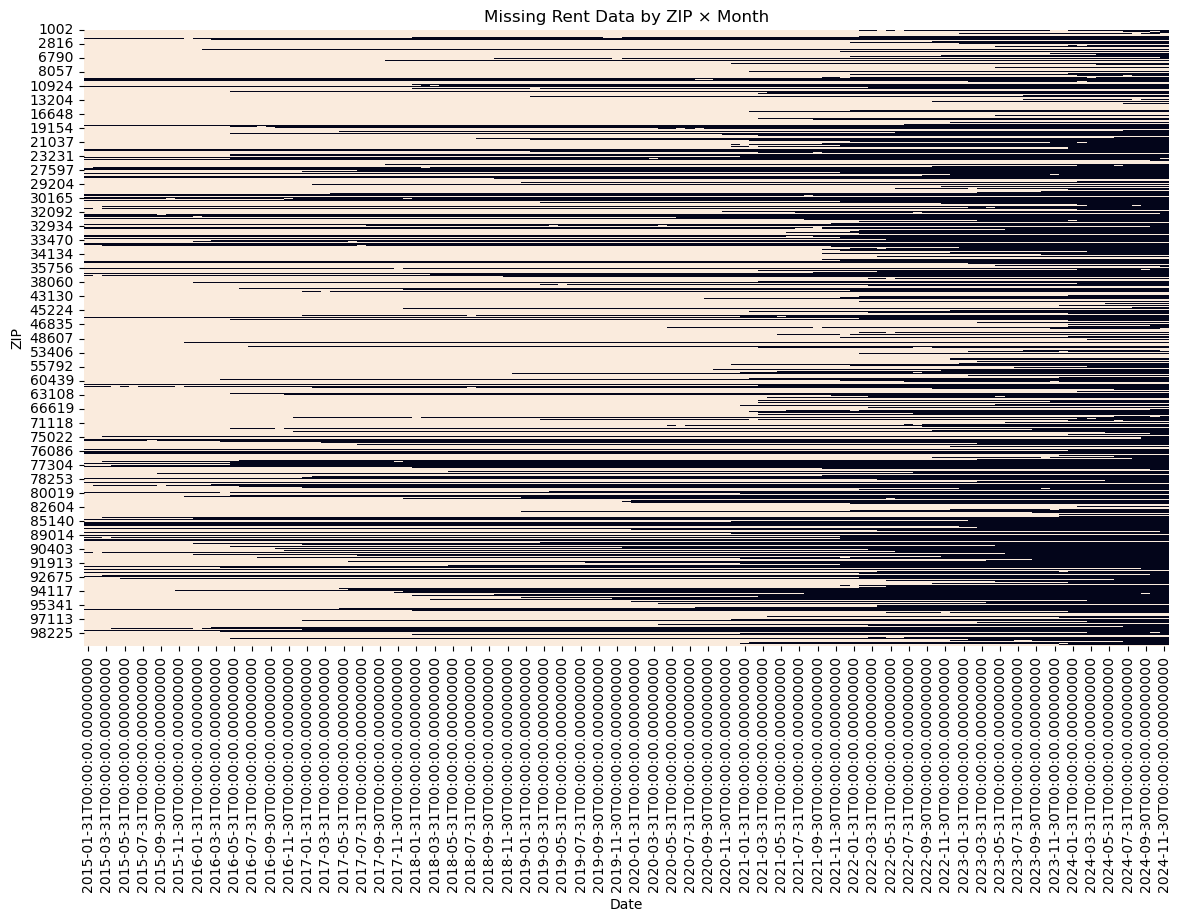

In [13]:
sample = zori2.pivot(index='ZIP', columns='Date', values='Rent')
plt.figure(figsize=(14,8))
sns.heatmap(sample.isna(), cbar=False)
plt.title("Missing Rent Data by ZIP × Month")

#### <b>Interpolate Rent</b>
Forecasts would either skip over missing data, distorting seasonality detection, giving biased parameter estimates, or create artificial jumps for forecasts and in the case volality distort means and standard deviations (create volatility where it might not exist)

Interpolate with spline (cubic) method and defaulting to linear interpolation for extremely sparse ZIPs (where non-missing months < 4). Because ZIP-level rental series can contain gaps, especially in less-populated areas, apply a uniform spline interpolation method to produce continuous monthly rent series. Spline interpolation is widely used in economics for reconstructing smooth time-series signals, and it is specifically appropriate for rental markets, where prices exhibit gradual month-to-month evolution (Waller et al. 2025; Zillow Research 2023).

Unlike linear interpolation, which introduces sharp corners, or forward-fill, which creates artificial jumps, cubic splines preserve the smoothness and persistence that characterize rent dynamics. This method is also consistent with Zillow’s own repeat-rent smoothing methodology.

Alternatives like LOCF would distort seasonality, mean imputation would flatten the signal, and more aggressive smoothing would erase volatility.

In [14]:
# method to apply strategy outlined above
def interpolate_zip(series):
    s = series.astype(float).copy()
    n_obs = s.notna().sum()
    
    # 0 points: nothing we can do
    if n_obs == 0:
        return s

    # 1–3 points: spline (order is 3) can't be fit so default to linear
    if n_obs < 4:
        return s.interpolate(method='linear', limit_direction='both')

    # 4+ points: safe to use cubic spline
    return s.interpolate(method='spline', order=3, limit_direction='both')

In [15]:
df_interpolated = (
    zori2
        .groupby('ZIP', group_keys=False)
        .apply(lambda g: g.assign(Rent=interpolate_zip(g['Rent'])))
        .reset_index(drop=True)
)

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/missing.py:604: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  terp = interpolate.UnivariateSpline(x, y, k=order, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/missing.py:604: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  terp = interpolate.UnivariateSpline(x, y, k=order, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/missing.py:604: UserWarning: 
The maximal number of iterations maxit (se

In [16]:
df_interpolated

,ZIP,Date,RegionID,SizeRank,RegionType,StateName,State,City,Metro,CountyName,Rent,gap_days
0,1002,2015-01-31,58197,3911,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,-2.738525e+07,NaN
1,1002,2015-02-28,58197,3911,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,-2.660452e+07,28.0
2,1002,2015-03-31,58197,3911,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,-2.583876e+07,31.0
3,1002,2015-04-30,58197,3911,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,-2.508783e+07,30.0
4,1002,2015-05-31,58197,3911,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,-2.435160e+07,31.0
...,...,...,...,...,...,...,...,...,...,...,...,...
934502,99801,2024-07-31,100459,4499,zip,AK,AK,Juneau,"Juneau, AK",Juneau Borough,NaN,31.0
934503,99801,2024-08-31,100459,4499,zip,AK,AK,Juneau,"Juneau, AK",Juneau Borough,NaN,31.0
934504,99801,2024-09-30,100459,4499,zip,AK,AK,Juneau,"Juneau, AK",Juneau Borough,NaN,30.0
934505,99801,2024-10-31,100459,4499,zip,AK,AK,Juneau,"Juneau, AK",Juneau Borough,NaN,31.0


In [17]:
# Check how many zips still have missing rental data after interpolation
df_interpolated['missing_after'] = df_interpolated.groupby('ZIP')['Rent'].transform(lambda s: s.isna().sum())

missing_summary = (
    df_interpolated.groupby('ZIP')['Rent']
         .apply(lambda s: s.isna().sum())
         .reset_index(name='missing_count')
)

# How many ZIPs have missing values?
num_zip_with_missing = (missing_summary['missing_count'] > 0).sum()

num_zip_with_missing

np.int64(2020)

In [18]:
# proportion of missing vs total zips
total_zips = missing_summary.shape[0]
percentage = num_zip_with_missing / total_zips * 100
percentage

np.float64(25.72265376289316)

#### <b>Drop ZIPs with Large Gaps in Rent History</b>
Imputation may not be reliable for zip codes where >24 consecutive months are missing, so drop those zip codes.

In [19]:
def longest_gap(s):
    mask = s.isna()
    return mask.groupby((~mask).cumsum()).sum().max()

zip_bad = (
    df_interpolated.groupby('ZIP')['Rent']
                   .apply(longest_gap)
                   .reset_index(name='longest_gap')
)

good_zips = zip_bad[zip_bad['longest_gap'] <= 24]['ZIP']

good_zips.nunique()

5833

In [20]:
df_interpolated_final = df_interpolated[df_interpolated['ZIP'].isin(good_zips)]

### B. City
Examine missing data and extract from US Postal Service - USPS returns the primary city for a ZIP code.

In [21]:
search = SearchEngine()

def get_city(zipcode):
    z = search.by_zipcode(zipcode)
    return z.major_city

In [22]:
# Get the primary city for each ZIP code
df_interpolated_final['ZIP'] = (
    df_interpolated_final['ZIP']
        .astype(str)
        .str.zfill(5)   # fix any that aren't padded correctly 1002 -> 01002
)

unique_zips = df_interpolated_final['ZIP'].drop_duplicates()

zip_city_map = {
    z: get_city(z) for z in unique_zips
}

df_interpolated_final['City'] = df_interpolated_final['ZIP'].map(zip_city_map)

/var/folders/v6/rt7shrqx5sldb75bkwymnhlw0000gp/T/ipykernel_30524/1513242167.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_interpolated_final['ZIP'] = (
/var/folders/v6/rt7shrqx5sldb75bkwymnhlw0000gp/T/ipykernel_30524/1513242167.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_interpolated_final['City'] = df_interpolated_final['ZIP'].map(zip_city_map)


In [23]:
df_interpolated_final.isna().sum()

ZIP                 0
Date                0
RegionID            0
SizeRank            0
RegionType          0
StateName           0
State               0
City                0
Metro               0
CountyName          0
Rent                0
gap_days         5833
missing_after       0
dtype: int64

## 4. Feature Engineering
Create a volatility measure for historical volatility

In [24]:
df_interpolated_final.loc[:, 'pct_change'] = (df_interpolated_final.groupby('ZIP')['Rent'].transform(lambda s: s.pct_change()))

df_interpolated_final.loc[:, 'Volatility'] = (df_interpolated_final.groupby('ZIP')['pct_change'].transform(lambda s: s.rolling(12, min_periods=6).std()))

/var/folders/v6/rt7shrqx5sldb75bkwymnhlw0000gp/T/ipykernel_30524/1531162160.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_interpolated_final.loc[:, 'pct_change'] = (df_interpolated_final.groupby('ZIP')['Rent'].transform(lambda s: s.pct_change()))
/var/folders/v6/rt7shrqx5sldb75bkwymnhlw0000gp/T/ipykernel_30524/1531162160.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_interpolated_final.loc[:, 'Volatility'] = (df_interpolated_final.groupby('ZIP')['pct_change'].transform(lambda s: s.rolling(1

## 5. Output
Remove unnecessary columns and output to csv and parquet files.

In [25]:
df_final = df_interpolated_final.copy()
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 694127 entries, 0 to 934268
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   ZIP            694127 non-null  object        
 1   Date           694127 non-null  datetime64[ns]
 2   RegionID       694127 non-null  int64         
 3   SizeRank       694127 non-null  int64         
 4   RegionType     694127 non-null  object        
 5   StateName      694127 non-null  object        
 6   State          694127 non-null  object        
 7   City           694127 non-null  object        
 8   Metro          694127 non-null  object        
 9   CountyName     694127 non-null  object        
 10  Rent           694127 non-null  float64       
 11  gap_days       688294 non-null  float64       
 12  missing_after  694127 non-null  int64         
 13  pct_change     688294 non-null  float64       
 14  Volatility     659129 non-null  float64       
dtypes: da

In [26]:
cols_to_drop = ['StateName', 'gap_days', 'missing_after', 'pct_change']
df_final = df_final.drop(columns=cols_to_drop)
df_final.head()

,ZIP,Date,RegionID,SizeRank,RegionType,State,City,Metro,CountyName,Rent,Volatility
0,01002,2015-01-31,58197,3911,zip,MA,Amherst,"Springfield, MA",Hampshire County,-2.738525e+07,NaN
1,01002,2015-02-28,58197,3911,zip,MA,Amherst,"Springfield, MA",Hampshire County,-2.660452e+07,NaN
2,01002,2015-03-31,58197,3911,zip,MA,Amherst,"Springfield, MA",Hampshire County,-2.583876e+07,NaN
3,01002,2015-04-30,58197,3911,zip,MA,Amherst,"Springfield, MA",Hampshire County,-2.508783e+07,NaN
4,01002,2015-05-31,58197,3911,zip,MA,Amherst,"Springfield, MA",Hampshire County,-2.435160e+07,NaN


In [27]:
df_final.to_csv('clean_zori.csv', index=False)
df_final.to_parquet('clean_zori.parquet', index=False, compression='snappy')